# 03 - Arquitectura Línea de Base: RNN Simple
## Clasificación de Marcha Patológica

**Autor:** Weimar Andres Arenas Gonzalez  
**Curso:** Fundamentos de Deep Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WeimarArenas/ProyectoDL20261/blob/main/03%20-%20Arquitectura_linea_base_RNN.ipynb)

---
**Objetivo:** Implementar y evaluar una RNN simple como arquitectura de línea de base.
Este modelo establece el nivel de rendimiento mínimo que los modelos más complejos (LSTM, GRU, Transformer) deben superar.

**Referencia paper:** RNN básica → 86.23% accuracy (Jun et al., 2020, LOSO-CV, todos los joints)

In [1]:
import sys

# TensorFlow requiere Python 3.10-3.12
if sys.version_info >= (3, 13):
    raise EnvironmentError(
        "Python " + str(sys.version_info.major) + "." + str(sys.version_info.minor) +
        " no es compatible con TensorFlow.\n"
        "Opciones:\n"
        "  1. Ejecuta este notebook en Google Colab (recomendado, tiene GPU gratuita)\n"
        "  2. Cambia el kernel a Python 3.10, 3.11 o 3.12"
    )

import subprocess
pkgs = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "tensorflow"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs,
               capture_output=True, timeout=300)
print(f"Python {sys.version_info.major}.{sys.version_info.minor} - Dependencias listas.")


Python 3.10 - Dependencias listas.


## 1. Configuración del entorno

In [2]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
from collections import Counter

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow: 2.21.0
GPU disponible: False


## 2. Carga de datos preprocesados

In [3]:
# ============================================================
# FUNCIONES DE CARGA — Formato real del dataset GIST
# CSV: tab-separado, sin header, 101 columnas
# Col 0: timestamp | cols (1+j*4)+1,+2,+3 = x,y,z para joint j
# Directorio padre: human{N}_{gait_type}{rep}/
# ============================================================

import re as _re

# Indices de features: x,y,z de cada articulacion (omite timestamp y joint_id)
FEATURE_COLS = []
for _j in range(25):
    _base = 1 + _j * 4
    FEATURE_COLS.extend([_base + 1, _base + 2, _base + 3])
# Resultado: [2,3,4, 6,7,8, ..., 98,99,100]  -> 75 valores por fila

_GAIT_PAT = _re.compile(
    r'human(\d+)_(normal|antalgic|lurch|steppage|stiff_legged|trendelenburg)\d+'
)
CLASS_MAP = {
    'normal': 0, 'antalgic': 1, 'stiff_legged': 2,
    'lurch': 3, 'steppage': 4, 'trendelenburg': 5,
}
CLASS_NAMES = ['Normal', 'Antalgic', 'Stiff-legged', 'Lurching', 'Steppage', 'Trendelenburg']


def extract_label_and_subject(filepath):
    """Extrae clase y sujeto del nombre del directorio padre del CSV."""
    dirname = os.path.basename(os.path.dirname(filepath))
    m = _GAIT_PAT.match(dirname)
    if not m:
        return None, None
    return CLASS_MAP.get(m.group(2)), int(m.group(1))


def load_csv_sequence(filepath, skip_frames=10, n_frames=50):
    """
    Lee un CSV del GIST dataset (tab-separado, 101 cols, sin header).
    Retorna array (n_frames, 75) omitiendo los primeros skip_frames.
    """
    try:
        df = pd.read_csv(filepath, header=None, sep='\t')
        if df.shape[1] != 101 or len(df) < skip_frames + n_frames:
            return None
        seq = df.iloc[skip_frames:skip_frames + n_frames, FEATURE_COLS].values.astype(np.float32)
        return None if np.any(np.isnan(seq)) else seq
    except Exception:
        return None


def load_full_dataset(data_dir, verbose=True):
    """
    Carga todos los CSV validos del GIST dataset.
    data_dir: ruta a Pathological_Gaits/
    Retorna: X (N,50,75), y (N,), S (N,)
    """
    sequences, labels, subjects = [], [], []
    skipped = 0
    for dirname in sorted(os.listdir(data_dir)):
        dirpath = os.path.join(data_dir, dirname)
        if not os.path.isdir(dirpath):
            continue
        for fname in sorted(os.listdir(dirpath)):
            if not fname.endswith('.csv'):
                continue
            fpath = os.path.join(dirpath, fname)
            label, subject = extract_label_and_subject(fpath)
            if label is None:
                skipped += 1
                continue
            seq = load_csv_sequence(fpath)
            if seq is None:
                skipped += 1
                continue
            sequences.append(seq)
            labels.append(label)
            subjects.append(subject)
    if verbose:
        print(f'Secuencias cargadas: {len(sequences)} | Descartadas: {skipped}')
    return (np.array(sequences, dtype=np.float32),
            np.array(labels, dtype=np.int32),
            np.array(subjects, dtype=np.int32))


In [4]:
# ---- Cargar datos (desde .npy cache o desde CSV) ----------------------------
if not os.path.exists('pathological_gait_datasets'):
    os.system('git clone --quiet https://github.com/kooksung/pathological_gait_datasets.git')

DATA_DIR = 'pathological_gait_datasets/Pathological_Gaits'

if os.path.exists('cache/X_all.npy') and os.path.exists('cache/y_labels.npy'):
    X = np.load('cache/X_all.npy')
    y = np.load('cache/y_labels.npy')
    S = np.load('cache/S_subjects.npy')
    print(f'Datos cargados desde .npy: X={X.shape}')
else:
    assert os.path.isdir(DATA_DIR), f'No se encontro el dataset en: {DATA_DIR}'
    X, y, S = load_full_dataset(DATA_DIR)
    np.save('cache/X_all.npy', X)
    np.save('cache/y_labels.npy', y)
    np.save('cache/S_subjects.npy', S)
    print(f'Datos cargados desde CSV y guardados: X={X.shape}')

# Constantes
N_CLASSES = 6
LEG_JOINT_INDICES = [0, 1, 12, 13, 14, 15, 16, 17, 18, 19]

def select_joints(X, joint_indices):
    """Selecciona articulaciones del tensor (N, T, 75) -> (N, T, len*3)."""
    feat = [f for j in joint_indices for f in [j*3, j*3+1, j*3+2]]
    return X[:, :, feat]

X_legs = select_joints(X, LEG_JOINT_INDICES)

print(f'X={X.shape} | X_legs={X_legs.shape}')
print(f'Clases: {dict(zip(*np.unique(y, return_counts=True)))}')
print(f'Sujetos: {sorted(np.unique(S))}')

Datos cargados desde .npy: X=(7157, 50, 75)
X=(7157, 50, 75) | X_legs=(7157, 50, 30)
Clases: {0: 1157, 1: 1200, 2: 1200, 3: 1200, 4: 1200, 5: 1200}
Sujetos: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [5]:
# ── Modo de entrenamiento ────────────────────────────────────────────────────
# QUICK_MODE = True  → rapido en CPU/VSCode  (~1-2 min por fold)
# QUICK_MODE = False → completo en Colab GPU (mejores resultados)
QUICK_MODE = True

N_EPOCHS   = 10  if QUICK_MODE else 500
PATIENCE   = 3   if QUICK_MODE else 30
BATCH_SIZE = 256 if QUICK_MODE else 64

modo_str = "RAPIDO (CPU)" if QUICK_MODE else "COMPLETO (GPU/Colab)"
print(f"Modo: {modo_str}")
print(f"Epocas max={N_EPOCHS} | Patience={PATIENCE} | Batch={BATCH_SIZE}")

Modo: RAPIDO (CPU)
Epocas max=10 | Patience=3 | Batch=256


## 3. Arquitectura RNN Simple

Siguiendo el mismo diseño del paper: 4 capas recurrentes con 125 neuronas + capa FC + Softmax.

In [6]:
def build_simple_rnn(input_shape, n_classes=6, n_layers=4, n_units=125,
                     dropout_rate=0.3, l2_reg=1e-4):
    """
    Construye una RNN simple de n_layers capas.
    
    Arquitectura (siguiendo Jun et al. 2020):
      Input → [ReLU → SimpleRNN × n_layers] → Dense(125, ReLU) → Softmax(6)
    
    Parámetros:
        input_shape: (T, F) — (50, 75) o (50, 30)
        n_classes: número de clases (6)
        n_layers: número de capas recurrentes (4)
        n_units: neuronas por capa (125)
        dropout_rate: tasa de dropout para regularización
        l2_reg: regularización L2
    """
    reg = keras.regularizers.l2(l2_reg)
    
    inputs = layers.Input(shape=input_shape, name='input')
    
    # Activación ReLU en la entrada (tal como describe el paper, Eq. 1)
    x = layers.Dense(n_units, activation='relu',
                      kernel_regularizer=reg, name='input_dense')(inputs)
    
    # Capas SimpleRNN apiladas
    for i in range(n_layers):
        return_seq = (i < n_layers - 1)  # Última capa no retorna secuencia
        x = layers.SimpleRNN(
            n_units,
            return_sequences=return_seq,
            kernel_regularizer=reg,
            recurrent_regularizer=reg,
            name=f'rnn_{i+1}'
        )(x)
        if i < n_layers - 1:
            x = layers.Dropout(dropout_rate, name=f'dropout_{i+1}')(x)
    
    # Capa fully connected
    x = layers.Dense(n_units, activation='relu',
                      kernel_regularizer=reg, name='fc')(x)
    x = layers.Dropout(dropout_rate, name='dropout_fc')(x)
    
    # Clasificador Softmax
    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs, name='SimpleRNN_Classifier')
    return model


# Ejemplo de modelo con todos los joints
model_example = build_simple_rnn(input_shape=(50, 75))
model_example.summary()

Model: "SimpleRNN_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 50, 75)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_dense (Dense)             │ (None, 50, 125)        │         9,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (SimpleRNN)               │ (None, 50, 125)        │        31,375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 125)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_2 (SimpleRNN)               │ (None, 50, 125)        │        31,375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 125)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_3 (SimpleRNN)               │ (None, 50, 125)        │        31,375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50, 125)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_4 (SimpleRNN)               │ (None, 125)            │        31,375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 125)            │        15,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_fc (Dropout)            │ (None, 125)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           756 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,506 (591.82 KB)

 Trainable params: 151,506 (591.82 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Entrenamiento con LOSO-CV

Se entrena el modelo en 10 folds de LOSO-CV para evaluar la generalización a sujetos no vistos,
consistente con la metodología del paper.

In [7]:
def evaluate_fold(model, X_test, y_test, class_names):
    """
    Evalúa un modelo en el fold de test y retorna métricas detalladas.
    Incluye accuracy, sensibilidad, especificidad y precisión por clase
    siguiendo la Tabla 4 del paper Jun et al. 2020.
    """
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    # Métricas por clase
    n_classes = len(class_names)
    sensitivity = np.zeros(n_classes)  # Recall = TP / (TP + FN)
    specificity = np.zeros(n_classes)  # TN / (TN + FP)
    precision = np.zeros(n_classes)    # TP / (TP + FP)
    
    for cls in range(n_classes):
        TP = cm[cls, cls]
        FN = cm[cls, :].sum() - TP
        FP = cm[:, cls].sum() - TP
        TN = cm.sum() - TP - FN - FP
        
        sensitivity[cls] = TP / (TP + FN) if (TP + FN) > 0 else 0
        specificity[cls] = TN / (TN + FP) if (TN + FP) > 0 else 0
        precision[cls]   = TP / (TP + FP) if (TP + FP) > 0 else 0
    
    return {
        'accuracy': acc,
        'confusion_matrix': cm,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'y_pred': y_pred,
        'y_true': y_test
    }


def train_loso_cv(X_data, y, S, model_builder_fn, n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
                  patience=PATIENCE, model_name='model', verbose_fold=True):
    """
    Ejecuta LOSO-CV completo: entrena y evalúa en los 10 folds.
    
    Parámetros:
        X_data:           tensor de entrada (N, T, F)
        y:                etiquetas (N,)
        S:                IDs de sujeto (N,)
        model_builder_fn: función que construye el modelo Keras
        n_epochs:         máximo de épocas (Early Stopping puede detener antes)
        batch_size:       tamaño de batch
        patience:         épocas de paciencia para Early Stopping
    Retorna:
        results: lista de resultados por fold
    """
    logo = LeaveOneGroupOut()
    results = []
    fold_accuracies = []
    
    print(f'\n=== LOSO-CV: {model_name} ===' )
    print(f'Total folds: {logo.get_n_splits(X_data, y, S)}')
    print(f'Épocas máx: {n_epochs}, Batch: {batch_size}, Patience: {patience}')
    print('-' * 60)
    
    start_total = time.time()
    
    for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X_data, y, groups=S)):
        test_subject = np.unique(S[test_idx])[0]
        
        # Separar y normalizar
        X_train_raw = X_data[train_idx]
        X_test_raw = X_data[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        
        N_tr, T, F = X_train_raw.shape
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw.reshape(-1, F)).reshape(N_tr, T, F)
        X_test = scaler.transform(X_test_raw.reshape(-1, F)).reshape(len(test_idx), T, F)
        
        # One-hot encoding
        y_train_oh = to_categorical(y_train, num_classes=N_CLASSES)
        
        # Construir modelo
        model = model_builder_fn(input_shape=(T, F))
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Callbacks
        callbacks = [
            EarlyStopping(monitor='val_accuracy', patience=patience,
                          restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=PATIENCE, min_lr=1e-6, verbose=0)
        ]
        
        # Entrenar
        fold_start = time.time()
        history = model.fit(
            X_train, y_train_oh,
            epochs=n_epochs,
            batch_size=batch_size,
            validation_split=0.1,  # 10% del train como validación
            callbacks=callbacks,
            verbose=0
        )
        fold_time = time.time() - fold_start
        
        # Evaluar
        fold_metrics = evaluate_fold(model, X_test, y_test, CLASS_NAMES)
        fold_metrics['history'] = history.history
        fold_metrics['fold'] = fold_idx
        fold_metrics['test_subject'] = int(test_subject)
        fold_metrics['epochs_trained'] = len(history.history['loss'])
        fold_metrics['time_sec'] = fold_time
        
        results.append(fold_metrics)
        fold_accuracies.append(fold_metrics['accuracy'])
        
        if verbose_fold:
            print(f"Fold {fold_idx:2d} | Sujeto {test_subject:2d} | "
                  f"Acc={fold_metrics['accuracy']*100:.2f}% | "
                  f"Épocas={fold_metrics['epochs_trained']:3d} | "
                  f"Tiempo={fold_time:.1f}s")
    
    total_time = time.time() - start_total
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    
    print('-' * 60)
    print(f'LOSO-CV Accuracy: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%')
    print(f'Tiempo total: {total_time/60:.1f} min')
    
    return results


print('Funciones de entrenamiento definidas.')

Funciones de entrenamiento definidas.


In [8]:
# Entrenar RNN simple con TODOS los joints
# Referencia: RNN básica del paper → 86.23%

results_rnn_all = train_loso_cv(
    X_data=X,
    y=y,
    S=S,
    model_builder_fn=lambda input_shape: build_simple_rnn(input_shape, n_classes=N_CLASSES),
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    model_name='SimpleRNN (todos los joints)'
)

acc_all = [r['accuracy'] for r in results_rnn_all]
print(f'\n→ Accuracy LOSO-CV (todos joints): {np.mean(acc_all)*100:.2f}% ± {np.std(acc_all)*100:.2f}%')
print(f'→ Referencia paper (RNN básica): 86.23%')


=== LOSO-CV: SimpleRNN (todos los joints) ===
Total folds: 10
Épocas máx: 10, Batch: 256, Patience: 3
------------------------------------------------------------
Fold  0 | Sujeto  1 | Acc=66.67% | Épocas= 10 | Tiempo=87.1s
Fold  1 | Sujeto  2 | Acc=84.43% | Épocas= 10 | Tiempo=76.3s
Fold  2 | Sujeto  3 | Acc=63.23% | Épocas= 10 | Tiempo=76.9s
Fold  3 | Sujeto  4 | Acc=73.65% | Épocas= 10 | Tiempo=118.9s
Fold  4 | Sujeto  5 | Acc=63.75% | Épocas= 10 | Tiempo=97.2s
Fold  5 | Sujeto  6 | Acc=69.72% | Épocas= 10 | Tiempo=80.5s
Fold  6 | Sujeto  7 | Acc=75.10% | Épocas= 10 | Tiempo=86.8s
Fold  7 | Sujeto  8 | Acc=53.33% | Épocas=  9 | Tiempo=75.5s
Fold  8 | Sujeto  9 | Acc=88.19% | Épocas= 10 | Tiempo=106.6s
Fold  9 | Sujeto 10 | Acc=44.86% | Épocas=  6 | Tiempo=50.7s
------------------------------------------------------------
LOSO-CV Accuracy: 68.29% ± 12.47%
Tiempo total: 14.8 min

→ Accuracy LOSO-CV (todos joints): 68.29% ± 12.47%
→ Referencia paper (RNN básica): 86.23%


In [9]:
# Entrenar RNN simple con solo joints de PIERNAS
X_legs = select_joints(X, LEG_JOINT_INDICES)

results_rnn_legs = train_loso_cv(
    X_data=X_legs,
    y=y,
    S=S,
    model_builder_fn=lambda input_shape: build_simple_rnn(input_shape, n_classes=N_CLASSES),
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    patience=PATIENCE,
    model_name='SimpleRNN (solo piernas)'
)

acc_legs = [r['accuracy'] for r in results_rnn_legs]
print(f'\n→ Accuracy LOSO-CV (solo piernas): {np.mean(acc_legs)*100:.2f}% ± {np.std(acc_legs)*100:.2f}%')


=== LOSO-CV: SimpleRNN (solo piernas) ===
Total folds: 10
Épocas máx: 10, Batch: 256, Patience: 3
------------------------------------------------------------
Fold  0 | Sujeto  1 | Acc=70.14% | Épocas= 10 | Tiempo=80.2s
Fold  1 | Sujeto  2 | Acc=71.81% | Épocas=  7 | Tiempo=55.6s
Fold  2 | Sujeto  3 | Acc=51.53% | Épocas=  8 | Tiempo=65.0s
Fold  3 | Sujeto  4 | Acc=56.19% | Épocas=  5 | Tiempo=53.8s
Fold  4 | Sujeto  5 | Acc=63.75% | Épocas=  6 | Tiempo=50.6s
Fold  5 | Sujeto  6 | Acc=59.03% | Épocas= 10 | Tiempo=78.8s
Fold  6 | Sujeto  7 | Acc=63.98% | Épocas=  7 | Tiempo=59.7s
Fold  7 | Sujeto  8 | Acc=61.39% | Épocas= 10 | Tiempo=80.6s
Fold  8 | Sujeto  9 | Acc=75.97% | Épocas= 10 | Tiempo=80.0s
Fold  9 | Sujeto 10 | Acc=77.22% | Épocas= 10 | Tiempo=89.4s
------------------------------------------------------------
LOSO-CV Accuracy: 65.10% ± 8.08%
Tiempo total: 12.0 min

→ Accuracy LOSO-CV (solo piernas): 65.10% ± 8.08%


## 5. Análisis de resultados

--- Resultados: SimpleRNN — Todos los joints ---


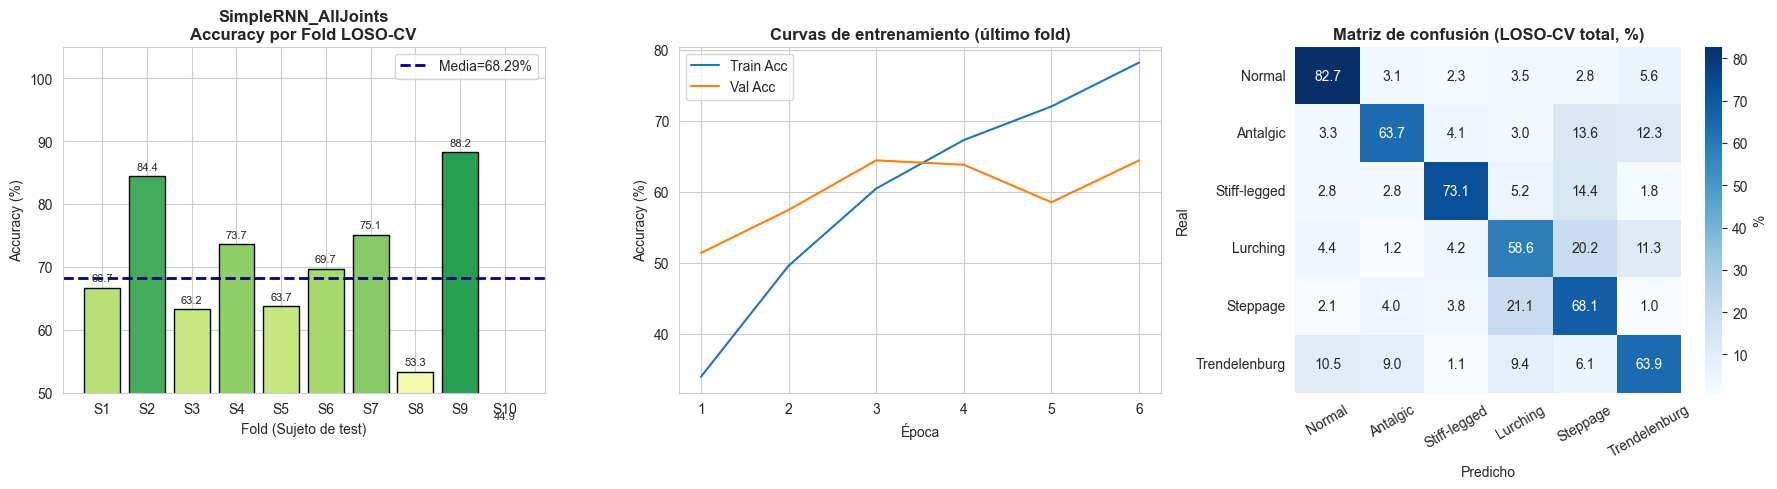

In [10]:
os.makedirs('figuras/NB03', exist_ok=True)
def plot_loso_results(results, model_name, class_names):
    """Visualiza accuracy por fold, curvas de entrenamiento y matriz de confusión global."""
    n_folds = len(results)
    accuracies = [r['accuracy'] for r in results]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Accuracy por fold
    axes[0].bar(range(n_folds), [a*100 for a in accuracies],
                color=[plt.cm.RdYlGn(a) for a in accuracies], edgecolor='black')
    axes[0].axhline(np.mean(accuracies)*100, color='navy', linestyle='--',
                    label=f'Media={np.mean(accuracies)*100:.2f}%', linewidth=2)
    axes[0].set_title(f'{model_name}\nAccuracy por Fold LOSO-CV', fontweight='bold')
    axes[0].set_xlabel('Fold (Sujeto de test)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_xticks(range(n_folds))
    axes[0].set_xticklabels([f'S{r["test_subject"]}' for r in results])
    axes[0].legend()
    axes[0].set_ylim(50, 105)
    for i, a in enumerate(accuracies):
        axes[0].text(i, a*100 + 1, f'{a*100:.1f}', ha='center', fontsize=8)
    
    # 2. Curvas de entrenamiento del último fold
    last_history = results[-1]['history']
    epochs = range(1, len(last_history['loss']) + 1)
    axes[1].plot(epochs, [a*100 for a in last_history['accuracy']], label='Train Acc')
    axes[1].plot(epochs, [a*100 for a in last_history['val_accuracy']], label='Val Acc')
    axes[1].set_title('Curvas de entrenamiento (último fold)', fontweight='bold')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    
    # 3. Matriz de confusión acumulada
    cm_total = np.zeros((len(class_names), len(class_names)), dtype=int)
    for r in results:
        cm_total += r['confusion_matrix']
    
    cm_pct = cm_total.astype(float) / cm_total.sum(axis=1, keepdims=True) * 100
    cls_labels = [class_names[i] for i in range(len(class_names))]
    
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=cls_labels, yticklabels=cls_labels,
                ax=axes[2], cbar_kws={'label': '%'})
    axes[2].set_title('Matriz de confusión (LOSO-CV total, %)', fontweight='bold')
    axes[2].set_xlabel('Predicho')
    axes[2].set_ylabel('Real')
    axes[2].tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.savefig(f'figuras/NB03/{model_name.replace(" ","_")}_results.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    return cm_total


print('--- Resultados: SimpleRNN — Todos los joints ---')
cm_all = plot_loso_results(results_rnn_all, 'SimpleRNN_AllJoints', CLASS_NAMES)

--- Resultados: SimpleRNN — Solo Piernas ---


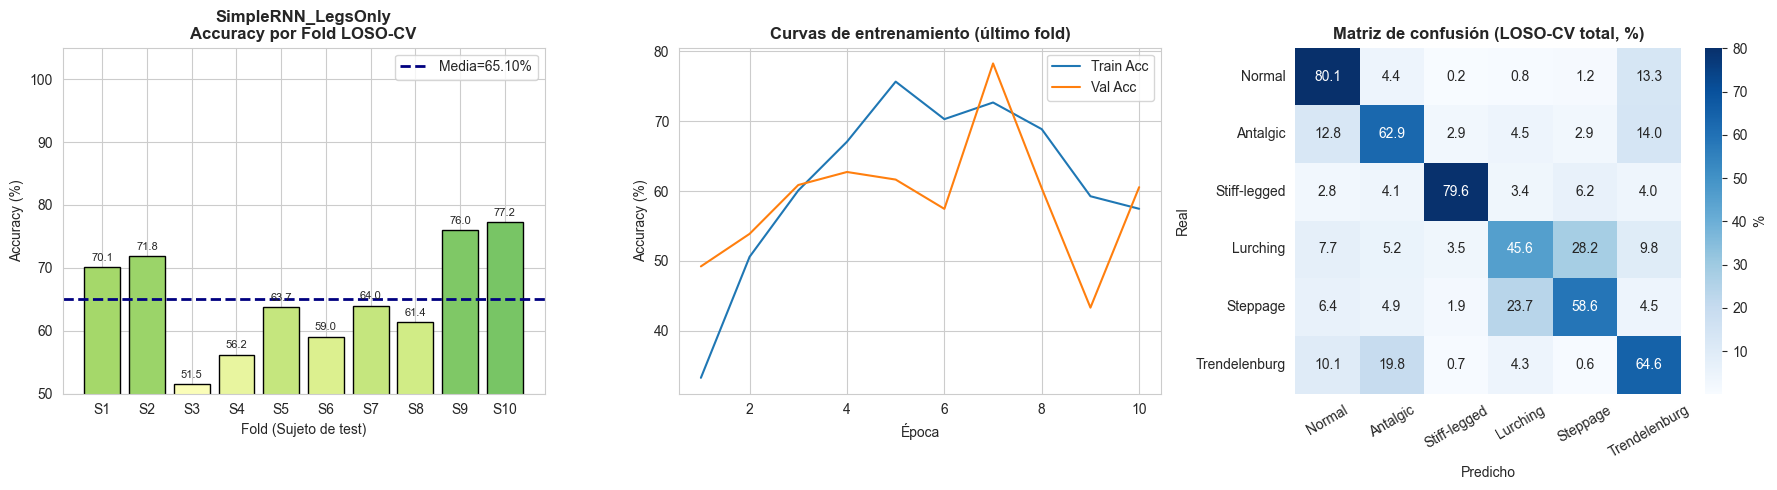

In [11]:
print('--- Resultados: SimpleRNN — Solo Piernas ---')
cm_legs = plot_loso_results(results_rnn_legs, 'SimpleRNN_LegsOnly', CLASS_NAMES)

In [12]:
# Métricas detalladas: sensibilidad, especificidad y precisión por clase
def print_detailed_metrics(results, model_name, class_names):
    """Imprime tabla de métricas por clase (siguiendo Tabla 4 del paper)."""
    n_cls = len(class_names)
    
    # Promediar métricas sobre los folds
    mean_sens = np.mean([r['sensitivity'] for r in results], axis=0)
    mean_spec = np.mean([r['specificity'] for r in results], axis=0)
    mean_prec = np.mean([r['precision'] for r in results], axis=0)
    mean_acc = np.mean([r['accuracy'] for r in results])
    
    print(f'\n=== Métricas LOSO-CV — {model_name} ===')
    print(f'{"Clase":22s} {"Sensib.":>10} {"Especif.":>10} {"Precisión":>10}')
    print('-' * 55)
    for cls_id in range(n_cls):
        print(f'{class_names[cls_id]:22s} {mean_sens[cls_id]*100:9.2f}% {mean_spec[cls_id]*100:9.2f}% {mean_prec[cls_id]*100:9.2f}%')
    print('-' * 55)
    print(f'{"PROMEDIO":22s} {mean_sens.mean()*100:9.2f}% {mean_spec.mean()*100:9.2f}% {mean_prec.mean()*100:9.2f}%')
    print(f'\nAccuracy global LOSO-CV: {mean_acc*100:.2f}%')


print_detailed_metrics(results_rnn_all, 'SimpleRNN (todos joints)', CLASS_NAMES)
print_detailed_metrics(results_rnn_legs, 'SimpleRNN (solo piernas)', CLASS_NAMES)


=== Métricas LOSO-CV — SimpleRNN (todos joints) ===
Clase                     Sensib.   Especif.  Precisión
-------------------------------------------------------
Normal                     83.23%     95.37%     82.99%
Antalgic                   63.67%     95.99%     67.37%
Stiff-legged               73.08%     96.91%     88.60%
Lurching                   58.58%     91.53%     57.73%
Steppage                   68.08%     88.60%     65.94%
Trendelenburg              63.92%     93.52%     73.67%
-------------------------------------------------------
PROMEDIO                   68.43%     93.65%     72.72%

Accuracy global LOSO-CV: 68.29%

=== Métricas LOSO-CV — SimpleRNN (solo piernas) ===
Clase                     Sensib.   Especif.  Precisión
-------------------------------------------------------
Normal                     80.45%     92.07%     75.87%
Antalgic                   62.92%     92.25%     64.43%
Stiff-legged               79.58%     98.15%     91.16%
Lurching             

## 6. Guardado de resultados

In [13]:
# Guardar resultados para comparación en notebook 07
results_summary = {
    'SimpleRNN_AllJoints': {
        'accuracies': [r['accuracy'] for r in results_rnn_all],
        'mean_acc': np.mean([r['accuracy'] for r in results_rnn_all]),
        'std_acc': np.std([r['accuracy'] for r in results_rnn_all]),
        'sensitivity': np.mean([r['sensitivity'] for r in results_rnn_all], axis=0).tolist(),
        'specificity': np.mean([r['specificity'] for r in results_rnn_all], axis=0).tolist(),
        'precision': np.mean([r['precision'] for r in results_rnn_all], axis=0).tolist(),
    },
    'SimpleRNN_LegsOnly': {
        'accuracies': [r['accuracy'] for r in results_rnn_legs],
        'mean_acc': np.mean([r['accuracy'] for r in results_rnn_legs]),
        'std_acc': np.std([r['accuracy'] for r in results_rnn_legs]),
        'sensitivity': np.mean([r['sensitivity'] for r in results_rnn_legs], axis=0).tolist(),
        'specificity': np.mean([r['specificity'] for r in results_rnn_legs], axis=0).tolist(),
        'precision': np.mean([r['precision'] for r in results_rnn_legs], axis=0).tolist(),
    }
}

with open('cache/results_rnn.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

print('Resultados guardados en results_rnn.pkl')
print(f'\nResumen final:')
print(f'  SimpleRNN (todos joints): {results_summary["SimpleRNN_AllJoints"]["mean_acc"]*100:.2f}%')
print(f'  SimpleRNN (solo piernas): {results_summary["SimpleRNN_LegsOnly"]["mean_acc"]*100:.2f}%')
print(f'  Referencia paper:          86.23%')
print(f'\n→ Siguiente: Notebook 04 - LSTM y GRU')

Resultados guardados en results_rnn.pkl

Resumen final:
  SimpleRNN (todos joints): 68.29%
  SimpleRNN (solo piernas): 65.10%
  Referencia paper:          86.23%

→ Siguiente: Notebook 04 - LSTM y GRU
